# Phase 4 — Anomaly & Outlier Detection

**Home Credit Default Risk** · KDD Phase 4

## Tujuan
1. **Statistical**: IQR + Z-score per fitur (univariat)
2. **Structural**: Isolation Forest (multivariat, tree-based) dengan 3 contamination levels
3. **Cross-reference**: Combine dengan Phase 2 DBSCAN noise labels
4. **Investigate**: Klasifikasi tipe anomali (A=Data Error, B=Rare Valid, C=Risk Signal)
5. **Business report** + rekomendasi tindakan

## Input
- `datasets/final/features_clustering.csv` (Phase 1)
- `datasets/final/cluster_labels.csv` (Phase 2 — termasuk DBSCAN IS_OUTLIER)

## Output → `results/phase4_anomaly/`
- `data_numeric.csv`, `data_with_labels.csv`
- `statistical_outliers.csv` (IQR + Z-score per row)
- `isolation_forest_outliers.csv` (3 contamination levels)
- `anomaly_combined.csv` (cross-method)
- `anomaly_summary.csv`
- `anomaly_investigation.csv`, `anomaly_investigation.txt`
- `business_report.txt`
- Visualisasi: `plot_*.png`

## 1. Setup & Load

In [1]:
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = PROJECT_ROOT / 'results/phase4_anomaly'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = PROJECT_ROOT / 'datasets/final/features_clustering.csv'
LABELS_PATH = PROJECT_ROOT / 'datasets/final/cluster_labels.csv'

RANDOM_SEED = 42
SAMPLE_SIZE = 50000
IQR_MULTIPLIER = 1.5
ZSCORE_THRESHOLD = 3.0
CONTAMINATIONS = [0.01, 0.05, 0.10]
DEFAULT_CONTAM = 0.05
MULTI_COL_RULE = 3  # outlier if flagged in >=3 columns

print(f'Loading features ...')
features = pd.read_csv(FEATURES_PATH)
labels = pd.read_csv(LABELS_PATH)
if 'ROW_ID' not in features.columns:
    features['ROW_ID'] = features.index
df_merged = pd.merge(features, labels, on='ROW_ID', how='inner')
print(f'  features: {features.shape}')
print(f'  labels  : {labels.shape}')
print(f'  merged  : {df_merged.shape}')

label_cols = ['ROW_ID', 'CLUSTER_KMEANS', 'CLUSTER_HIER', 'CLUSTER_DBSCAN', 'IS_OUTLIER']
numeric_cols = [c for c in df_merged.select_dtypes(include=['number']).columns if c not in label_cols]
df_features = df_merged[numeric_cols].copy()
null_pct = df_features.isnull().mean()
drop_cols = null_pct[null_pct > 0.5].index.tolist()
if drop_cols:
    print(f'  dropping {len(drop_cols)} cols >50% null: {drop_cols}')
    df_features = df_features.drop(columns=drop_cols)
df_features = df_features.fillna(df_features.median())

df_numeric = pd.concat([df_merged[['ROW_ID']].reset_index(drop=True), df_features.reset_index(drop=True)], axis=1)
df_with_labels = pd.concat([df_numeric, df_merged[['CLUSTER_KMEANS','IS_OUTLIER']].reset_index(drop=True)], axis=1)
df_numeric.to_csv(OUT_DIR / 'data_numeric.csv', index=False)
df_with_labels.to_csv(OUT_DIR / 'data_with_labels.csv', index=False)
print(f'\nNumeric features: {df_features.shape[1]}')
print(f'Saved data_numeric.csv & data_with_labels.csv')

Loading features ...


  features: (356255, 68)
  labels  : (356255, 5)
  merged  : (356255, 72)



Numeric features: 67
Saved data_numeric.csv & data_with_labels.csv


## 2. Statistical Outlier Detection — IQR + Z-score

**IQR**: outlier = nilai di luar [Q1 - 1.5×IQR, Q3 + 1.5×IQR]. Robust terhadap distribusi skewed.

**Z-score**: outlier = |z| > 3. Asumsi distribusi Gaussian; sensitif terhadap distribusi tidak normal.

**Rule kombinasi**: row dianggap statistical outlier jika flagged di ≥ 3 kolom (cegah false positive dari satu fitur ekstrem).

In [2]:
def flag_iqr(df, mult=1.5):
    flags = pd.DataFrame(False, index=df.index, columns=df.columns)
    for col in df.columns:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        flags[col] = (df[col] < Q1 - mult*IQR) | (df[col] > Q3 + mult*IQR)
    return flags

def flag_zscore(df, thr=3.0):
    z = np.abs(stats.zscore(df, nan_policy='omit'))
    return pd.DataFrame(z > thr, index=df.index, columns=df.columns)

sample = df_numeric.sample(n=min(SAMPLE_SIZE, len(df_numeric)), random_state=RANDOM_SEED).reset_index(drop=True)
row_ids = sample['ROW_ID']
feat_sample = sample.drop(columns=['ROW_ID'])

print(f'Sample: {len(sample):,} rows × {feat_sample.shape[1]} features')

print('Running IQR ...')
t0 = time.time()
iqr_flags = flag_iqr(feat_sample, mult=IQR_MULTIPLIER)
iqr_count = iqr_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')

print('Running Z-score ...')
t0 = time.time()
z_flags = flag_zscore(feat_sample, thr=ZSCORE_THRESHOLD)
z_count = z_flags.sum(axis=1)
print(f'  Done in {time.time()-t0:.1f}s')

stats_df = pd.DataFrame({
    'ROW_ID': row_ids,
    'iqr_outlier_count': iqr_count,
    'zscore_outlier_count': z_count,
    'is_iqr_outlier': iqr_count >= MULTI_COL_RULE,
    'is_zscore_outlier': z_count >= MULTI_COL_RULE,
})
stats_df['is_statistical_outlier'] = stats_df['is_iqr_outlier'] | stats_df['is_zscore_outlier']
def get_method(r):
    if r['is_iqr_outlier'] and r['is_zscore_outlier']: return 'Both'
    if r['is_iqr_outlier']: return 'IQR'
    if r['is_zscore_outlier']: return 'Z-score'
    return 'None'
stats_df['statistical_method'] = stats_df.apply(get_method, axis=1)
stats_df.to_csv(OUT_DIR / 'statistical_outliers.csv', index=False)

print(f'\n--- Statistical Summary ---')
print(f'  IQR outliers      : {int(stats_df["is_iqr_outlier"].sum()):,}')
print(f'  Z-score outliers  : {int(stats_df["is_zscore_outlier"].sum()):,}')
print(f'  Statistical (any) : {int(stats_df["is_statistical_outlier"].sum()):,}')
print(f'  Both methods      : {int((stats_df["statistical_method"]=="Both").sum()):,}')

print('\nTop 5 features triggering IQR outliers:')
print(iqr_flags.sum().sort_values(ascending=False).head(5).to_string())

Sample: 50,000 rows × 67 features
Running IQR ...


  Done in 0.2s


Running Z-score ...


  Done in 0.2s



--- Statistical Summary ---
  IQR outliers      : 39,928
  Z-score outliers  : 4,060
  Statistical (any) : 39,928
  Both methods      : 4,060

Top 5 features triggering IQR outliers:
EXT_SOURCE_1                            22737
REGION_RATING_CLIENT_W_CITY             12851
NAME_EDUCATION_TYPE_Higher education    12120
INST_PAYMENT_RATIO_MEAN                 10766
CC_AMT_BALANCE_MEAN                      9797


## 3. Isolation Forest — Multivariate Anomaly Detection

Isolation Forest = ensemble pohon partisi acak. Anomali ter-isolasi di splits awal → average path length pendek → score rendah.

Dijalankan dengan **3 contamination level** (0.01, 0.05, 0.10) untuk sensitivity analysis. Default = 0.05.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_sample)
iso_df = pd.DataFrame({'ROW_ID': row_ids})

for c in CONTAMINATIONS:
    print(f'Running Isolation Forest (contamination={c}) ...')
    t0 = time.time()
    iso = IsolationForest(n_estimators=100, contamination=c, random_state=RANDOM_SEED, n_jobs=-1)
    preds = iso.fit_predict(X_scaled)
    scores = iso.score_samples(X_scaled)
    iso_df[f'is_isolation_outlier_{c}'] = (preds == -1)
    iso_df[f'isolation_score_{c}'] = scores
    print(f'  Done in {time.time()-t0:.1f}s | outliers={int((preds==-1).sum())}')

iso_df['is_isolation_outlier'] = iso_df[f'is_isolation_outlier_{DEFAULT_CONTAM}']
iso_df['isolation_score'] = iso_df[f'isolation_score_{DEFAULT_CONTAM}']
iso_df.to_csv(OUT_DIR / 'isolation_forest_outliers.csv', index=False)

print(f'\nDefault (contam={DEFAULT_CONTAM}): {int(iso_df["is_isolation_outlier"].sum()):,} outliers')
print(f'Score range: {iso_df["isolation_score"].min():.4f} to {iso_df["isolation_score"].max():.4f}')

Running Isolation Forest (contamination=0.01) ...


  Done in 1.9s | outliers=500
Running Isolation Forest (contamination=0.05) ...


  Done in 1.8s | outliers=2500
Running Isolation Forest (contamination=0.1) ...


  Done in 1.7s | outliers=5000



Default (contam=0.05): 2,500 outliers
Score range: -0.6002 to -0.3564


## 4. Cross-reference dengan DBSCAN (Phase 2)

Combine 3 sumber sinyal: IQR, Z-score, Isolation Forest, + DBSCAN noise dari Phase 2.

**Detection count**:
- 4 = ekstrem konsisten
- 3 = HIGH_CONFIDENCE_ANOMALY
- 2 = MODERATE_ANOMALY
- 1 = WEAK_SIGNAL
- 0 = NORMAL

In [4]:
merged_a = pd.merge(stats_df, iso_df[['ROW_ID','is_isolation_outlier','isolation_score']], on='ROW_ID', how='inner')
merged_a = pd.merge(merged_a, labels[['ROW_ID','CLUSTER_KMEANS','IS_OUTLIER']], on='ROW_ID', how='inner')

merged_a['detection_count'] = (
    merged_a['is_iqr_outlier'].astype(int) +
    merged_a['is_zscore_outlier'].astype(int) +
    merged_a['is_isolation_outlier'].astype(int) +
    merged_a['IS_OUTLIER'].fillna(0).astype(int)
)

def categorize(r):
    if r['detection_count'] >= 3: return 'HIGH_CONFIDENCE_ANOMALY'
    if r['detection_count'] == 2: return 'MODERATE_ANOMALY'
    if r['detection_count'] == 1: return 'WEAK_SIGNAL'
    return 'NORMAL'
merged_a['anomaly_category'] = merged_a.apply(categorize, axis=1)
merged_a['phase2_validated'] = (merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY') & (merged_a['IS_OUTLIER']==1)

merged_a.to_csv(OUT_DIR / 'anomaly_combined.csv', index=False)

cat_dist = merged_a['anomaly_category'].value_counts()
high_conf = merged_a[merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']
cluster_dist = high_conf['CLUSTER_KMEANS'].value_counts().sort_index()
validated = int(merged_a['phase2_validated'].sum())

summary_df = pd.DataFrame({
    'Total_Evaluated': [len(merged_a)],
    'HIGH_CONFIDENCE': [int(cat_dist.get('HIGH_CONFIDENCE_ANOMALY', 0))],
    'Phase2_Validated_DBSCAN': [validated],
    'MODERATE': [int(cat_dist.get('MODERATE_ANOMALY', 0))],
    'WEAK': [int(cat_dist.get('WEAK_SIGNAL', 0))],
    'NORMAL': [int(cat_dist.get('NORMAL', 0))],
})
summary_df.to_csv(OUT_DIR / 'anomaly_summary.csv', index=False)

print('--- Distribusi Kategori Anomali ---')
for cat, cnt in cat_dist.items():
    pct = cnt / len(merged_a) * 100
    print(f'  {cat:25s}: {cnt:>6,} ({pct:5.1f}%)')
print(f'\nPhase 2 (DBSCAN) cross-validated: {validated}')
print(f'\nDistribusi HIGH_CONFIDENCE per cluster:')
for cid, cnt in cluster_dist.items():
    print(f'  Cluster {int(cid)}: {cnt:,}')

--- Distribusi Kategori Anomali ---
  WEAK_SIGNAL              : 34,741 ( 69.5%)
  NORMAL                   : 10,072 ( 20.1%)
  MODERATE_ANOMALY         :  3,775 (  7.5%)
  HIGH_CONFIDENCE_ANOMALY  :  1,412 (  2.8%)

Phase 2 (DBSCAN) cross-validated: 42

Distribusi HIGH_CONFIDENCE per cluster:
  Cluster 0: 165
  Cluster 1: 242
  Cluster 2: 137
  Cluster 3: 319
  Cluster 4: 549


## 5. Anomaly Investigation & Typology

Setiap high-confidence anomali diklasifikasi:
- **Tipe A — Data Error**: deviasi > 50× median cluster → kesalahan input/ETL
- **Tipe C — Risk Signal**: pola finansial kontradiktif (income rendah + credit besar, dst.) → underwriting wajib
- **Tipe B — Rare Valid**: extreme statistik tapi koheren → VHNW / tail customer

In [5]:
data_with = pd.read_csv(OUT_DIR / 'data_with_labels.csv')
high_conf_ids = merged_a[merged_a['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']['ROW_ID'].values
focus = data_with[data_with['ROW_ID'].isin(high_conf_ids)].copy()
full_numeric_only = data_with.drop(columns=['ROW_ID','IS_OUTLIER'])
cluster_medians = full_numeric_only.groupby('CLUSTER_KMEANS').median()

def get_extreme_features(row, top_n=5):
    cluster = row['CLUSTER_KMEANS']
    if cluster not in cluster_medians.index:
        return []
    medians = cluster_medians.loc[cluster]
    devs = {}
    for col in medians.index:
        if col in row.index and medians[col] != 0:
            devs[col] = abs(row[col] - medians[col]) / (abs(medians[col]) + 1e-9)
    return sorted(devs, key=devs.get, reverse=True)[:top_n]

def classify_type(row):
    cluster = row['CLUSTER_KMEANS']
    if cluster not in cluster_medians.index:
        return 'Tipe B - Rare but Valid'
    medians = cluster_medians.loc[cluster]
    max_dev = 0
    for col in medians.index:
        if col in row.index and medians[col] != 0:
            d = abs(row[col] - medians[col]) / (abs(medians[col]) + 1e-9)
            if d > max_dev: max_dev = d
    cols = row.index
    is_c = False
    if 'AMT_INCOME_TOTAL' in cols and 'AMT_CREDIT' in cols:
        if row['AMT_INCOME_TOTAL'] < -1.5 and row['AMT_CREDIT'] > 2.0:
            is_c = True
    if 'ANNUITY_TO_INCOME' in cols and row.get('ANNUITY_TO_INCOME', 0) > 3.0:
        is_c = True
    if 'EXT_SOURCE_1' in cols and (row.get('EXT_SOURCE_1', 0) > 1.5 or row.get('EXT_SOURCE_2', 0) > 1.5) and cluster == 4:
        is_c = True
    if max_dev > 50:
        return 'Tipe A - Data Error'
    if is_c:
        return 'Tipe C - Risk Signal'
    return 'Tipe B - Rare but Valid'

JUSTIFY = {
    'Tipe A - Data Error': 'Deviasi fitur > 50x median klaster — kemungkinan kesalahan input/ETL (overflow, salah unit, atau sentinel value tidak ter-handle).',
    'Tipe C - Risk Signal': 'Kombinasi finansial kontradiktif (mis. rasio cicilan/pendapatan ekstrem, income rendah + credit besar, atau skor eksternal tinggi di cluster bermasalah).',
    'Tipe B - Rare but Valid': 'Ekstrem secara statistik tapi koheren — kemungkinan tail-end legitimate customer (VHNW, kasus khusus).'
}
IMPACT = {
    'Tipe A - Data Error': 'Data Engineering: tambahkan capping rule (Z-score>3 di tahap ingest) untuk mencegah kontaminasi model.',
    'Tipe C - Risk Signal': 'Underwriting: matikan auto-approve, wajibkan manual review oleh underwriter senior + verifikasi pendapatan fisik.',
    'Tipe B - Rare but Valid': 'Routing: alihkan ke divisi Wealth Management / Priority Banking untuk potensi cross-sell.'
}

investigations = []
type_counts = {k: 0 for k in JUSTIFY.keys()}

# --- Build Markdown investigation log ---
md_inv = []
md_inv.append('# Phase 4 — Anomaly Investigation Log')
md_inv.append('**Dataset:** Home Credit Default Risk')
md_inv.append(f'**High-confidence anomalies investigated:** {len(high_conf_ids):,}')
md_inv.append('')
md_inv.append('---')
md_inv.append('')

TYPE_ICON = {
    'Tipe A - Data Error': '🔴 Tipe A — Data Error',
    'Tipe C - Risk Signal': '🟠 Tipe C — Risk Signal',
    'Tipe B - Rare but Valid': '🟢 Tipe B — Rare but Valid',
}

for _, row in focus.iterrows():
    top_feats = get_extreme_features(row, top_n=5)
    if row['CLUSTER_KMEANS'] in cluster_medians.index:
        medians = cluster_medians.loc[row['CLUSTER_KMEANS']]
        feat_parts = []
        for f in top_feats:
            val = row[f]; med = medians[f]
            mult = abs(val - med) / (abs(med) + 1e-9)
            feat_parts.append(f'`{f}` = {val:.2f} ({mult:.1f}x median)')
        feat_md = ', '.join(feat_parts)
    else:
        feat_md = '_unknown cluster_'
    atype = classify_type(row)
    type_counts[atype] += 1
    inv = {
        'ROW_ID': int(row['ROW_ID']),
        'Cluster': f"cluster_{int(row['CLUSTER_KMEANS'])}",
        'Anomaly Type': atype,
        'Top Deviating Features': feat_md,
        'Justification': JUSTIFY[atype],
        'Business Impact': IMPACT[atype],
    }
    investigations.append(inv)

    md_inv.append(f'## ROW_ID {inv["ROW_ID"]}')
    md_inv.append('')
    md_inv.append(f'| Field | Nilai |')
    md_inv.append(f'|-------|-------|')
    md_inv.append(f'| Cluster | `{inv["Cluster"]}` |')
    md_inv.append(f'| Tipe Anomali | **{TYPE_ICON.get(atype, atype)}** |')
    md_inv.append(f'| Top Deviating Features | {feat_md} |')
    md_inv.append(f'| Justifikasi | {JUSTIFY[atype]} |')
    md_inv.append(f'| Business Impact | {IMPACT[atype]} |')
    md_inv.append('')
    md_inv.append('---')
    md_inv.append('')

inv_df = pd.DataFrame(investigations)
inv_df.to_csv(OUT_DIR / 'anomaly_investigation.csv', index=False)
(OUT_DIR / 'anomaly_investigation.md').write_text('\n'.join(md_inv), encoding='utf-8')

print(f'Total investigated: {len(focus)}')
for k, v in type_counts.items():
    icon = {'Tipe A - Data Error': 'A', 'Tipe C - Risk Signal': 'C', 'Tipe B - Rare but Valid': 'B'}[k]
    print(f'  Tipe {icon}: {v:,}')
print(f'\nSaved anomaly_investigation.csv & anomaly_investigation.md')

Total investigated: 1412
  Tipe A: 844
  Tipe C: 23
  Tipe B: 545

Saved anomaly_investigation.csv & anomaly_investigation.md


## 6. Visualisasi

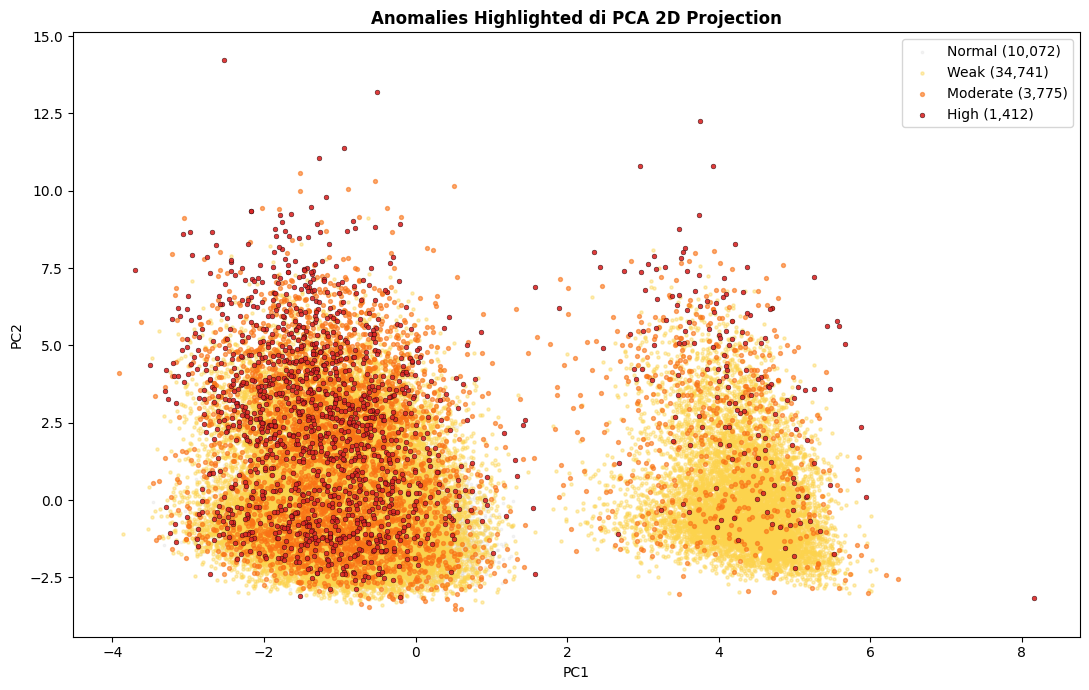

In [6]:
# PCA scatter dengan anomalies highlighted
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2 = pca.fit_transform(X_scaled)
merged_a_indexed = merged_a.reset_index(drop=True)
merged_a_indexed['PC1'] = X_pca2[:, 0]
merged_a_indexed['PC2'] = X_pca2[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))
normal = merged_a_indexed[merged_a_indexed['anomaly_category']=='NORMAL']
weak = merged_a_indexed[merged_a_indexed['anomaly_category']=='WEAK_SIGNAL']
moderate = merged_a_indexed[merged_a_indexed['anomaly_category']=='MODERATE_ANOMALY']
high = merged_a_indexed[merged_a_indexed['anomaly_category']=='HIGH_CONFIDENCE_ANOMALY']
ax.scatter(normal['PC1'], normal['PC2'], c='#CCCCCC', s=3, alpha=0.2, label=f'Normal ({len(normal):,})')
ax.scatter(weak['PC1'], weak['PC2'], c='#FCD34D', s=5, alpha=0.4, label=f'Weak ({len(weak):,})')
ax.scatter(moderate['PC1'], moderate['PC2'], c='#F97316', s=8, alpha=0.6, label=f'Moderate ({len(moderate):,})')
ax.scatter(high['PC1'], high['PC2'], c='#DC2626', s=12, alpha=0.9, label=f'High ({len(high):,})', edgecolors='black', linewidths=0.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Anomalies Highlighted di PCA 2D Projection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_pca_anomaly.png', dpi=150)
plt.show()

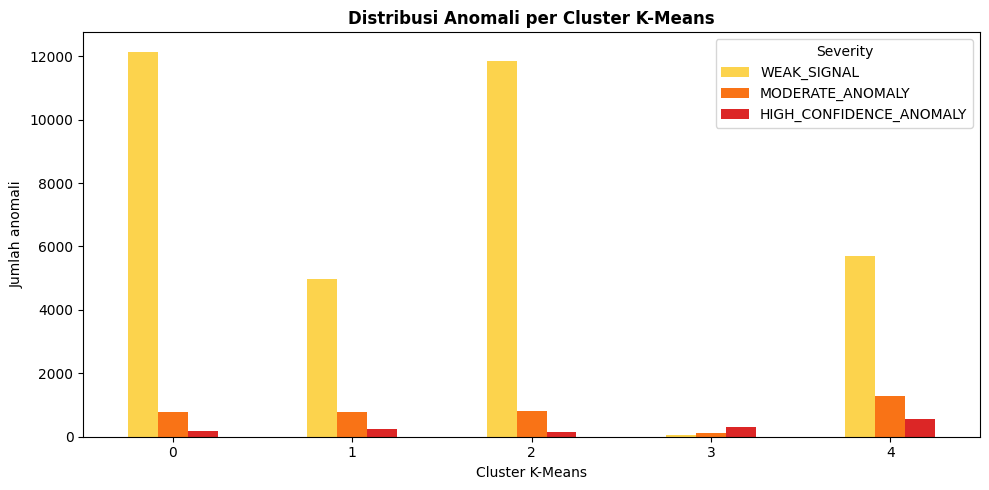

In [7]:
# Anomalies per cluster (heatmap-like bar)
cluster_anomalies = merged_a.groupby('CLUSTER_KMEANS')['anomaly_category'].value_counts().unstack(fill_value=0)
if 'NORMAL' in cluster_anomalies.columns:
    cluster_anomalies = cluster_anomalies.drop(columns=['NORMAL'])
cluster_anomalies_sorted = cluster_anomalies.reindex(columns=['WEAK_SIGNAL','MODERATE_ANOMALY','HIGH_CONFIDENCE_ANOMALY'])
fig, ax = plt.subplots(figsize=(10, 5))
cluster_anomalies_sorted.plot(kind='bar', stacked=False, ax=ax,
                              color=['#FCD34D','#F97316','#DC2626'])
ax.set_xlabel('Cluster K-Means'); ax.set_ylabel('Jumlah anomali')
ax.set_title('Distribusi Anomali per Cluster K-Means', fontweight='bold')
ax.legend(title='Severity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_anomaly_per_cluster.png', dpi=150)
plt.show()

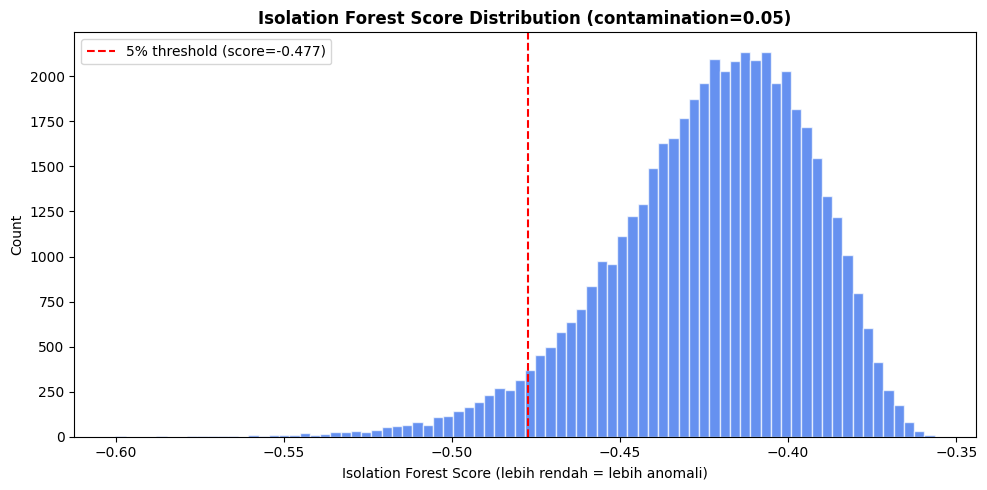

In [8]:
# Isolation Forest score distribution + threshold lines
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(iso_df['isolation_score'], bins=80, color='#2563EB', alpha=0.7, edgecolor='white')
thr05 = iso_df['isolation_score'].quantile(DEFAULT_CONTAM)
ax.axvline(thr05, color='red', ls='--', label=f'5% threshold (score={thr05:.3f})')
ax.set_xlabel('Isolation Forest Score (lebih rendah = lebih anomali)')
ax.set_ylabel('Count')
ax.set_title(f'Isolation Forest Score Distribution (contamination={DEFAULT_CONTAM})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_isolation_score_dist.png', dpi=150)
plt.show()

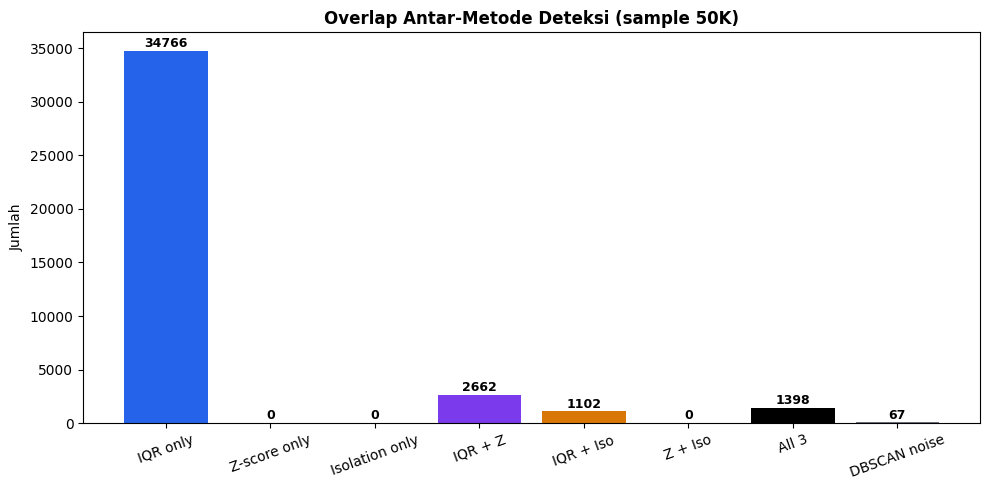

In [9]:
# Method overlap (Venn-ish bar)
n_iqr = int(merged_a['is_iqr_outlier'].sum())
n_z = int(merged_a['is_zscore_outlier'].sum())
n_iso = int(merged_a['is_isolation_outlier'].sum())
n_dbscan = int(merged_a['IS_OUTLIER'].fillna(0).sum())
n_iqr_z = int((merged_a['is_iqr_outlier'] & merged_a['is_zscore_outlier']).sum())
n_iqr_iso = int((merged_a['is_iqr_outlier'] & merged_a['is_isolation_outlier']).sum())
n_z_iso = int((merged_a['is_zscore_outlier'] & merged_a['is_isolation_outlier']).sum())
n_all3 = int((merged_a['is_iqr_outlier'] & merged_a['is_zscore_outlier'] & merged_a['is_isolation_outlier']).sum())

overlap_data = [
    ('IQR only', n_iqr - n_iqr_z - n_iqr_iso + n_all3),
    ('Z-score only', n_z - n_iqr_z - n_z_iso + n_all3),
    ('Isolation only', n_iso - n_iqr_iso - n_z_iso + n_all3),
    ('IQR + Z', n_iqr_z - n_all3),
    ('IQR + Iso', n_iqr_iso - n_all3),
    ('Z + Iso', n_z_iso - n_all3),
    ('All 3', n_all3),
    ('DBSCAN noise', n_dbscan),
]
fig, ax = plt.subplots(figsize=(10, 5))
labels_o = [x[0] for x in overlap_data]
vals_o = [x[1] for x in overlap_data]
colors_o = ['#2563EB','#059669','#DC2626','#7C3AED','#D97706','#F97316','#000','#6B7280']
bars = ax.bar(labels_o, vals_o, color=colors_o)
for bar, v in zip(bars, vals_o):
    ax.text(bar.get_x()+bar.get_width()/2, v+max(vals_o)*0.01, str(v), ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Jumlah')
ax.set_title('Overlap Antar-Metode Deteksi (sample 50K)', fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_method_overlap.png', dpi=150)
plt.show()

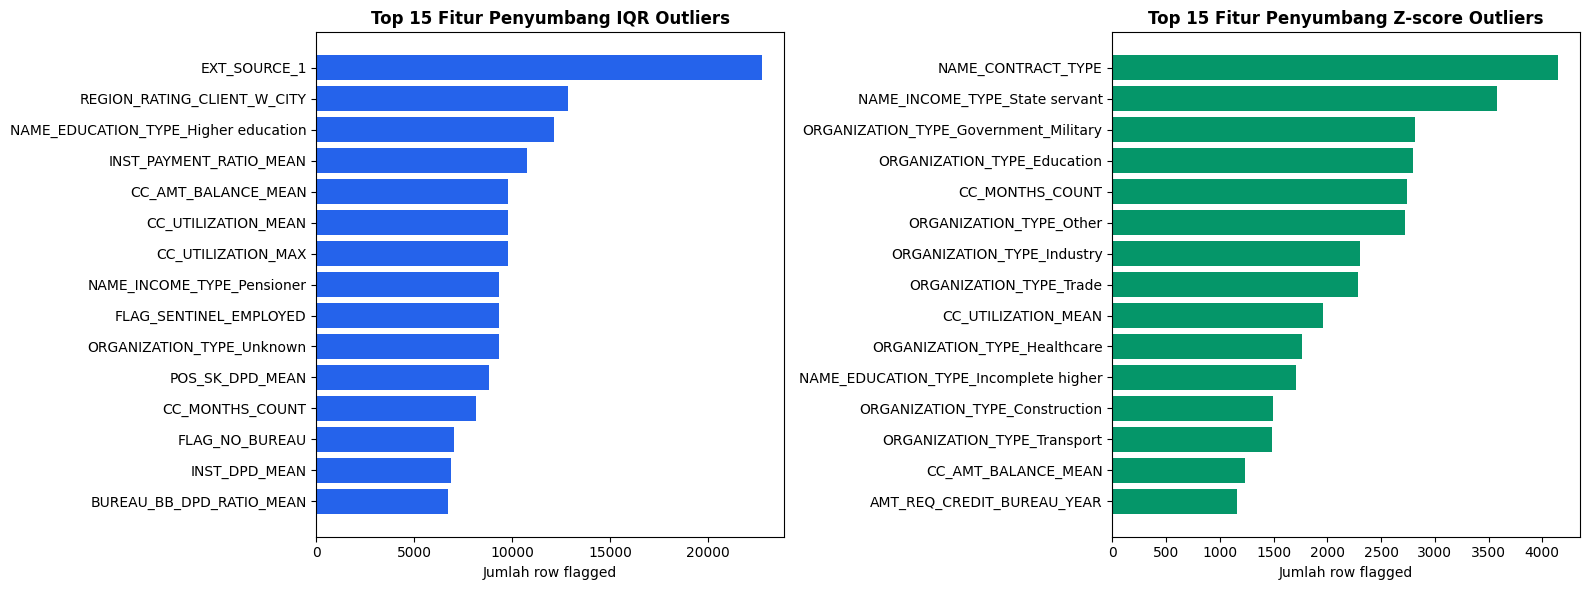

In [10]:
# Heatmap: top fitur penyumbang anomali
top_iqr_feats = iqr_flags.sum().sort_values(ascending=False).head(15)
top_z_feats = z_flags.sum().sort_values(ascending=False).head(15)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top_iqr_feats.index[::-1], top_iqr_feats.values[::-1], color='#2563EB')
axes[0].set_title('Top 15 Fitur Penyumbang IQR Outliers', fontweight='bold')
axes[0].set_xlabel('Jumlah row flagged')
axes[1].barh(top_z_feats.index[::-1], top_z_feats.values[::-1], color='#059669')
axes[1].set_title('Top 15 Fitur Penyumbang Z-score Outliers', fontweight='bold')
axes[1].set_xlabel('Jumlah row flagged')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_anomaly_heatmap.png', dpi=150)
plt.show()

## 7. Final Business Report

In [11]:
lines = []
lines.append('# Phase 4 — Anomaly & Outlier Detection')
lines.append('**Dataset:** Home Credit Default Risk')
lines.append('')
lines.append('---')
lines.append('')

lines.append('## Metodologi')
lines.append('')
lines.append('| Parameter | Nilai |')
lines.append('|-----------|-------|')
lines.append(f'| Sample size | {len(merged_a):,} dari {len(features):,} total aplikasi |')
lines.append(f'| IQR multiplier | {IQR_MULTIPLIER} |')
lines.append(f'| Z-score threshold | {ZSCORE_THRESHOLD} |')
lines.append(f'| Isolation Forest contaminations | {CONTAMINATIONS} (default = {DEFAULT_CONTAM}) |')
lines.append(f'| Multi-col rule | flagged jika anomali di >= {MULTI_COL_RULE} kolom |')
lines.append(f'| Cross-reference | Phase 2 DBSCAN noise (`IS_OUTLIER`) sebagai sumber ke-4 |')
lines.append('')
lines.append('---')
lines.append('')

lines.append('## Ringkasan Hasil')
lines.append('')
lines.append('| Kategori | Jumlah | Persentase |')
lines.append('|----------|--------|------------|')
for cat, cnt in cat_dist.items():
    pct = cnt / len(merged_a) * 100
    icon = {'HIGH_CONFIDENCE_ANOMALY': '🔴', 'MODERATE_ANOMALY': '🟠', 'WEAK_SIGNAL': '🟡', 'NORMAL': '🟢'}.get(cat, '')
    lines.append(f'| {icon} **{cat}** | {cnt:,} | {pct:.1f}% |')
lines.append('')
lines.append(f'> **Phase 2 DBSCAN cross-validation:** {validated} dari {int(cat_dist.get("HIGH_CONFIDENCE_ANOMALY",0))} high-confidence')
lines.append('> → konsistensi density-based (DBSCAN) dan tree-based (Isolation Forest) memperkuat reliabilitas.')
lines.append('')
lines.append('---')
lines.append('')

lines.append('## Distribusi High-Confidence per Cluster')
lines.append('')
lines.append('| Cluster | Nama | Anomali High-Confidence |')
lines.append('|---------|------|--------------------------|')
cluster_names = {0:'Veteran Aktif',1:'Peminjam Minimal',2:'CC Intensif',3:'Peminjam Ambisius',4:'Peminjam Bermasalah'}
for cid, cnt in cluster_dist.items():
    nm = cluster_names.get(int(cid), f'C{int(cid)}')
    lines.append(f'| {int(cid)} | {nm} | **{cnt:,}** |')
lines.append('')
lines.append('> **Interpretasi:** Cluster 4 (Peminjam Bermasalah) dan Cluster 3 (Ambisius) mendominasi anomali —')
lines.append('> konsisten dengan temuan Phase 3 bahwa profil demografis keduanya sangat bervariasi.')
lines.append('')
lines.append('---')
lines.append('')

lines.append('## Tipologi Anomali')
lines.append('')
lines.append('| Tipe | Jumlah | Justifikasi | Aksi Bisnis |')
lines.append('|------|--------|-------------|-------------|')
type_icons = {'Tipe A - Data Error': '🔴', 'Tipe C - Risk Signal': '🟠', 'Tipe B - Rare but Valid': '🟢'}
for atype, cnt in type_counts.items():
    icon = type_icons.get(atype, '')
    lines.append(f'| {icon} **{atype}** | {cnt:,} | {JUSTIFY[atype]} | {IMPACT[atype]} |')
lines.append('')
lines.append('---')
lines.append('')

lines.append('## Rekomendasi untuk Bank')
lines.append('')
lines.append('### 1. ETL Hardening (Tipe A — Data Error)')
lines.append('Tambahkan capping otomatis di pipeline ingestion: setiap nilai dengan')
lines.append('Z-score > 5 di-flag untuk QA manual sebelum masuk warehouse.')
lines.append('Fitur prioritas: `DAYS_EMPLOYED`, `INST_DPD_MAX`, `AMT_INCOME_TOTAL`.')
lines.append('')
lines.append('### 2. Underwriting Alert (Tipe C — Risk Signal)')
lines.append(f'{int(type_counts["Tipe C - Risk Signal"])} kasus dengan profil kontradiktif → matikan auto-approve.')
lines.append('Wajibkan verifikasi pendapatan fisik + manual review oleh underwriter senior.')
lines.append('Rule deteksi terpenting: `income_low + credit_large + burden_high`.')
lines.append('')
lines.append('### 3. Priority Routing (Tipe B — Rare Valid)')
lines.append(f'{int(type_counts["Tipe B - Rare but Valid"]):,} tail-end customer berpotensi VHNW (Very High Net Worth Individual).')
lines.append('Routing ke divisi Wealth Management untuk cross-sell produk premium.')
lines.append('')
lines.append('### 4. Phase 2 Integration')
lines.append('DBSCAN noise sebagai indikator independen — tambahkan ke daily monitoring dashboard.')
lines.append('Rekening baru yang masuk DBSCAN noise + statistical outlier patut di-flag untuk audit.')
lines.append('')
lines.append('---')
lines.append('')

lines.append('## Data Mining Concepts — Phase 4')
lines.append('')
lines.append('| Metode | Cara Kerja | Keunggulan |')
lines.append('|--------|------------|------------|')
lines.append('| **IQR** | Rentang interkuartil [Q1-1.5IQR, Q3+1.5IQR] | Robust terhadap distribusi skewed |')
lines.append('| **Z-score** | Standar deviasi dari mean (\|z\| > 3) | Sensitif terhadap Gaussian outlier |')
lines.append('| **Isolation Forest** | Tree ensemble, path length pendek = anomali | Multivariate, menangkap interaksi fitur |')
lines.append('| **DBSCAN (Phase 2)** | Density-based noise detection | Independen dari threshold statistik |')
lines.append('')
lines.append('> **Cross-Method Validation:** Anomali yang ditemukan ≥2 metode = HIGH_CONFIDENCE.')
lines.append('> Jauh lebih reliabel daripada single-method detection.')
lines.append('')
lines.append('> **Anomaly Typology:** Tipe A = perbaiki ETL; Tipe C = eskalasi underwriting; Tipe B = route ke wealth.')
lines.append('')

report = '\n'.join(lines)
(OUT_DIR / 'business_report.md').write_text(report, encoding='utf-8')
print(f'Saved {OUT_DIR / "business_report.md"}')
print()
print(report[:2500])

Saved C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase4_anomaly\business_report.md

# Phase 4 — Anomaly & Outlier Detection
**Dataset:** Home Credit Default Risk

---

## Metodologi

| Parameter | Nilai |
|-----------|-------|
| Sample size | 50,000 dari 356,255 total aplikasi |
| IQR multiplier | 1.5 |
| Z-score threshold | 3.0 |
| Isolation Forest contaminations | [0.01, 0.05, 0.1] (default = 0.05) |
| Multi-col rule | flagged jika anomali di >= 3 kolom |
| Cross-reference | Phase 2 DBSCAN noise (`IS_OUTLIER`) sebagai sumber ke-4 |

---

## Ringkasan Hasil

| Kategori | Jumlah | Persentase |
|----------|--------|------------|
| 🟡 **WEAK_SIGNAL** | 34,741 | 69.5% |
| 🟢 **NORMAL** | 10,072 | 20.1% |
| 🟠 **MODERATE_ANOMALY** | 3,775 | 7.5% |
| 🔴 **HIGH_CONFIDENCE_ANOMALY** | 1,412 | 2.8% |

> **Phase 2 DBSCAN cross-validation:** 42 dari 1412 high-confidence
> → konsistensi density-based (DBSCAN) dan tree-based (Isolation Forest) memperkuat reliabilitas.

-

<>:92: SyntaxWarning: invalid escape sequence '\|'
<>:92: SyntaxWarning: invalid escape sequence '\|'
C:\Users\mario\AppData\Local\Temp\claude\ipykernel_31440\1006760782.py:92: SyntaxWarning: invalid escape sequence '\|'
  lines.append('| **Z-score** | Standar deviasi dari mean (\|z\| > 3) | Sensitif terhadap Gaussian outlier |')


---
**Phase 4 selesai.** Output di `results/phase4_anomaly/`